# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [30]:
# %pip install gymnasium
# %pip install "gymnasium[toy-text]"
# %pip install minigrid

In [31]:
import os
import glob
import shutil
from collections import defaultdict, deque

import gymnasium as gym
import minigrid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Gymnasium :", gym.__version__)
print("MiniGrid chargé :", minigrid.__version__)

Gymnasium : 1.2.3
MiniGrid chargé : 3.0.0


## 1. Découverte de Taxi-v3

In [32]:
env = gym.make("Taxi-v3")
print("action_space      :", env.action_space)
print("observation_space :", env.observation_space)
print("spec              :", env.spec)
print("unwrapped         :", env.unwrapped)

obs, info = env.reset(seed=0)
print("\nObservation initiale :", obs)
print("Info initiale        :", info)

print("\nInterprétation de l'état décodé (taxi_row, taxi_col, passenger_loc, destination) :")
print(list(env.unwrapped.decode(obs)))

env.close()

action_space      : Discrete(6)
observation_space : Discrete(500)
spec              : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
unwrapped         : <TaxiEnv<Taxi-v3>>

Observation initiale : 314
Info initiale        : {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)}

Interprétation de l'état décodé (taxi_row, taxi_col, passenger_loc, destination) :
[3, 0, 3, 2]


**Réponse :**

- `Taxi-v3` possède **6 actions discrètes** : sud, nord, est, ouest, `pickup`, `dropoff`.
- L’observation est un **entier discret parmi 500 états**. Cet entier encode :
  1. la position du taxi,
  2. la position du passager,
  3. la destination finale.
- Cet environnement est utile pour commencer car :
  - l’espace d’actions est petit ;
  - l’état peut être **décodé explicitement** ;
  - les règles sont simples à comprendre ;
  - on peut construire des politiques à la main assez facilement.

## 2. Premier épisode avec actions aléatoires

In [33]:
env = gym.make("Taxi-v3", render_mode="ansi")
obs, info = env.reset(seed=1)

total_reward = 0
steps = 0
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

print(env.render())
print("Nombre d'étapes   :", steps)
print("Récompense totale :", total_reward)
print("Terminated        :", terminated)
print("Truncated         :", truncated)
print("Cause d'arrêt     :", "succès / terminal" if terminated else "limite de temps")

env.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

Nombre d'étapes   : 200
Récompense totale : -668
Terminated        : False
Truncated         : True
Cause d'arrêt     : limite de temps


**Analyse :**

La politique aléatoire termine rarement de façon efficace. Elle enchaîne souvent des déplacements inutiles, des `pickup` invalides et des `dropoff` invalides, ce qui coûte cher en récompense. On observe donc beaucoup d’étapes pour une récompense totale très négative.

## 3. Politique aléatoire sur plusieurs épisodes

In [34]:
def random_taxi_policy(obs, info, env, step_idx):
    return env.action_space.sample()

def run_policy(env_id, policy_fn, episodes=30, seed=0, render_mode=None, max_steps=500, policy_state_factory=None):
    env = gym.make(env_id, render_mode=render_mode) if render_mode else gym.make(env_id)
    rows = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        terminated = truncated = False
        policy_state = policy_state_factory() if policy_state_factory else None

        while not (terminated or truncated) and steps < max_steps:
            if policy_state is None:
                action = policy_fn(obs, info, env, steps)
            else:
                action = policy_fn(obs, info, env, steps, policy_state)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        success = bool(terminated and total_reward > 0)
        rows.append({
            "episode": ep + 1,
            "reward": total_reward,
            "steps": steps,
            "success": success,
            "terminated": terminated,
            "truncated": truncated
        })

    env.close()
    return pd.DataFrame(rows)

taxi_random_results = run_policy("Taxi-v3", random_taxi_policy, episodes=30, seed=0)
taxi_random_results.head()

,episode,reward,steps,success,terminated,truncated
0,1,-875,200,False,False,True
1,2,-830,200,False,False,True
2,3,-677,200,False,False,True
3,4,-776,200,False,False,True
4,5,-767,200,False,False,True


In [35]:
def summarize_results(df, env_name, policy_name):
    return pd.Series({
        "Environnement": env_name,
        "Politique": policy_name,
        "Reward moyenne": round(df["reward"].mean(), 3),
        "Étapes moyennes": round(df["steps"].mean(), 3),
        "Taux de succès": round(100 * df["success"].mean(), 1)
    })

taxi_random_summary = summarize_results(taxi_random_results, "Taxi-v3", "Aléatoire")
display(taxi_random_summary.to_frame(name="Valeur"))

,Valeur
Environnement,Taxi-v3
Politique,Aléatoire
Reward moyenne,-790.167
Étapes moyennes,198.067
Taux de succès,0.0


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [36]:
def constrained_random_taxi_policy(obs, info, env, step_idx):
    action_mask = info.get("action_mask", None)
    if action_mask is None:
        return env.action_space.sample()

    valid_actions = [a for a, ok in enumerate(action_mask) if ok == 1]
    return int(np.random.choice(valid_actions))

taxi_constrained_results = run_policy("Taxi-v3", constrained_random_taxi_policy, episodes=50, seed=0)
taxi_constrained_results.head()

,episode,reward,steps,success,terminated,truncated
0,1,-200,200,False,False,True
1,2,-200,200,False,False,True
2,3,-200,200,False,False,True
3,4,-200,200,False,False,True
4,5,-200,200,False,False,True


In [37]:
taxi_random_summary = summarize_results(taxi_random_results, "Taxi-v3", "Aléatoire")
taxi_constrained_summary = summarize_results(taxi_constrained_results, "Taxi-v3", "Aléatoire contrainte")

taxi_compare_random = pd.DataFrame([taxi_random_summary, taxi_constrained_summary])
display(taxi_compare_random)

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,Taxi-v3,Aléatoire,-790.167,198.067,0.0
1,Taxi-v3,Aléatoire contrainte,-188.980,191.080,0.0


**Analyse :**

Le filtrage améliore les résultats car il évite des actions clairement invalides au regard de l’état courant, surtout `pickup` et `dropoff` dans de mauvaises situations.  
Cela réduit les pénalités inutiles, mais la politique reste limitée car elle ne sait toujours pas **où aller** : elle choisit encore ses déplacements au hasard.

## 5. Politique heuristique simple pour Taxi-v3

In [38]:
env = gym.make("Taxi-v3")
sample_obs, _ = env.reset(seed=3)
decoded = list(env.unwrapped.decode(sample_obs))

print("Observation encodée :", sample_obs)
print("État décodé         :", decoded)
print("Format : [taxi_row, taxi_col, passenger_loc, destination]")
env.close()

Observation encodée : 42
État décodé         : [0, 2, 0, 2]
Format : [taxi_row, taxi_col, passenger_loc, destination]


In [39]:
def can_move_taxi(row, col, action, env):
    desc = env.unwrapped.desc
    if action == 0:   # south
        return row < 4
    if action == 1:   # north
        return row > 0
    if action == 2:   # east
        return desc[1 + row, 2 * col + 2] == b":"
    if action == 3:   # west
        return desc[1 + row, 2 * col] == b":"
    return True

def apply_move_taxi(row, col, action):
    if action == 0:
        return min(row + 1, 4), col
    if action == 1:
        return max(row - 1, 0), col
    if action == 2:
        return row, min(col + 1, 4)
    if action == 3:
        return row, max(col - 1, 0)
    return row, col

def shortest_taxi_action(row, col, target_row, target_col, env):
    if (row, col) == (target_row, target_col):
        return None

    q = deque([(row, col)])
    visited = {(row, col)}
    parent = {}
    action_from_parent = {}

    while q:
        r, c = q.popleft()
        for a in [0, 1, 2, 3]:
            if can_move_taxi(r, c, a, env):
                nr, nc = apply_move_taxi(r, c, a)
                if (nr, nc) not in visited:
                    visited.add((nr, nc))
                    parent[(nr, nc)] = (r, c)
                    action_from_parent[(nr, nc)] = a
                    if (nr, nc) == (target_row, target_col):
                        q.clear()
                        break
                    q.append((nr, nc))

    cur = (target_row, target_col)
    if cur not in parent:
        return env.action_space.sample()

    actions = []
    while cur != (row, col):
        actions.append(action_from_parent[cur])
        cur = parent[cur]

    return actions[-1]

def heuristic_taxi_policy(obs, info, env, step_idx):
    taxi_row, taxi_col, passenger_loc, destination = list(env.unwrapped.decode(obs))

    if passenger_loc < 4:
        passenger_row, passenger_col = env.unwrapped.locs[passenger_loc]
        if (taxi_row, taxi_col) == (passenger_row, passenger_col):
            return 4  # pickup
        return shortest_taxi_action(taxi_row, taxi_col, passenger_row, passenger_col, env)

    destination_row, destination_col = env.unwrapped.locs[destination]
    if (taxi_row, taxi_col) == (destination_row, destination_col):
        return 5  # dropoff
    return shortest_taxi_action(taxi_row, taxi_col, destination_row, destination_col, env)

In [40]:
taxi_heuristic_results = run_policy("Taxi-v3", heuristic_taxi_policy, episodes=50, seed=0)
taxi_heuristic_summary = summarize_results(taxi_heuristic_results, "Taxi-v3", "Heuristique")
display(pd.DataFrame([taxi_random_summary, taxi_constrained_summary, taxi_heuristic_summary]))

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,Taxi-v3,Aléatoire,-790.167,198.067,0.0
1,Taxi-v3,Aléatoire contrainte,-188.980,191.080,0.0
2,Taxi-v3,Heuristique,7.840,13.160,100.0


**Analyse :**

Pour construire cette politique, il faut décoder l’observation afin d’obtenir :
- la position du taxi ;
- la position du passager ;
- la destination.

Les cas particuliers à gérer explicitement sont :
- quand le taxi est déjà sur la case du passager : il faut faire `pickup` ;
- quand le passager est déjà dans le taxi : il faut viser la destination ;
- quand le taxi est arrivé à la destination : il faut faire `dropoff` ;
- la présence de murs internes, qui empêchent certains déplacements directs.

## 6. Tableau comparatif pour Taxi-v3

In [41]:
taxi_table = pd.DataFrame([
    taxi_random_summary,
    taxi_constrained_summary,
    taxi_heuristic_summary
]).reset_index(drop=True)

display(taxi_table)

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,Taxi-v3,Aléatoire,-790.167,198.067,0.0
1,Taxi-v3,Aléatoire contrainte,-188.980,191.080,0.0
2,Taxi-v3,Heuristique,7.840,13.160,100.0


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [42]:
env = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env.reset(seed=0)

print("Type de l'observation :", type(obs))
print("Clés disponibles      :", obs.keys())
print("Forme de obs['image'] :", obs["image"].shape)
print("direction             :", obs["direction"])
print("mission               :", obs["mission"])
print("Espace d'action       :", env.action_space)

env.close()

Type de l'observation : <class 'dict'>
Clés disponibles      : dict_keys(['image', 'direction', 'mission'])
Forme de obs['image'] : (7, 7, 3)
direction             : 0
mission               : get to the green goal square
Espace d'action       : Discrete(7)


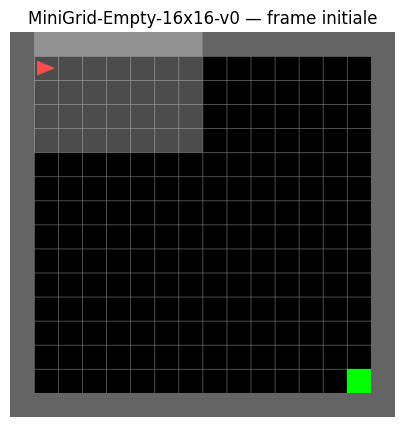

In [43]:
env = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env.reset(seed=0)
frame = env.render()

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0 — frame initiale")
plt.show()

env.close()

**Analyse :**

`MiniGrid` est plus difficile à lire directement que `Taxi-v3` car l’observation n’est pas un simple entier décodable.  
On reçoit ici une structure plus riche (`image`, `direction`, `mission`) liée à une perception locale de l’agent.  
L’exploration devient donc plus difficile car l’agent ne dispose pas d’une représentation aussi simple et explicite de l’état global.

## 8. Politique aléatoire sur MiniGrid

In [44]:
def minigrid_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

minigrid_random_results = run_policy(
    "MiniGrid-Empty-16x16-v0",
    minigrid_random_policy,
    episodes=20,
    seed=0,
    render_mode="rgb_array",
    max_steps=500
)
display(minigrid_random_results.head())
display(summarize_results(minigrid_random_results, "MiniGrid", "Aléatoire").to_frame(name="Valeur"))

,episode,reward,steps,success,terminated,truncated
0,1,0,500,False,False,False
1,2,0,500,False,False,False
2,3,0,500,False,False,False
3,4,0,500,False,False,False
4,5,0,500,False,False,False


,Valeur
Environnement,MiniGrid
Politique,Aléatoire
Reward moyenne,0.0
Étapes moyennes,500.0
Taux de succès,0.0


## 9. Politique réflexe minimale sur MiniGrid

In [45]:
A_LEFT, A_RIGHT, A_FORWARD = 0, 1, 2

def front_is_clear(env):
    cell = env.unwrapped.grid.get(*env.unwrapped.front_pos)
    return cell is None or cell.can_overlap()

def reflex_policy_factory():
    return {}

def minigrid_reflex_policy(obs, info, env, step_idx, state):
    # Politique réflexe volontairement limitée :
    # avancer si possible, mais tourner à droite toutes les 3 étapes.
    if step_idx % 3 == 2:
        return A_RIGHT
    return A_FORWARD if front_is_clear(env) else A_RIGHT

In [46]:
minigrid_reflex_results = run_policy(
    "MiniGrid-Empty-16x16-v0",
    minigrid_reflex_policy,
    episodes=20,
    seed=0,
    render_mode="rgb_array",
    max_steps=200,
    policy_state_factory=reflex_policy_factory
)

mini_random_summary = summarize_results(minigrid_random_results, "MiniGrid", "Aléatoire")
mini_reflex_summary = summarize_results(minigrid_reflex_results, "MiniGrid", "Réflexe minimale")

display(pd.DataFrame([mini_random_summary, mini_reflex_summary]))

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,MiniGrid,Aléatoire,0.0,500.0,0.0
1,MiniGrid,Réflexe minimale,0.0,200.0,0.0


**Analyse :**

Une politique purement réflexe peut tourner en rond car elle réagit seulement à la situation locale immédiate.  
Elle n’a ni carte globale, ni souvenir fiable des positions déjà visitées, ni vraie stratégie pour progresser vers l’objectif.

## 10. Politique d’exploration avec mémoire minimale

In [47]:
DIR_TO_VEC = {
    0: (1, 0),   # east
    1: (0, 1),   # south
    2: (-1, 0),  # west
    3: (0, -1)   # north
}

def memory_policy_factory():
    return {
        "visited": defaultdict(int),
        "recent_positions": deque(maxlen=8)
    }

def turn_towards(current_dir, target_dir):
    right_steps = (target_dir - current_dir) % 4
    left_steps = (current_dir - target_dir) % 4
    return A_LEFT if left_steps <= right_steps else A_RIGHT

def cell_is_free(env, pos):
    x, y = pos
    cell = env.unwrapped.grid.get(x, y)
    return cell is None or cell.can_overlap()

def minigrid_memory_policy(obs, info, env, step_idx, state):
    pos = tuple(env.unwrapped.agent_pos)
    direction = env.unwrapped.agent_dir
    state["visited"][pos] += 1
    state["recent_positions"].append(pos)

    goal = (14, 14)  # dans Empty-16x16-v0
    candidates = []

    for d, vec in DIR_TO_VEC.items():
        nxt = (pos[0] + vec[0], pos[1] + vec[1])
        if 0 <= nxt[0] < env.unwrapped.width and 0 <= nxt[1] < env.unwrapped.height and cell_is_free(env, nxt):
            score = state["visited"][nxt]
            if nxt in state["recent_positions"]:
                score += 2
            score += 0.05 * (abs(goal[0] - nxt[0]) + abs(goal[1] - nxt[1]))
            candidates.append((score, d, nxt))

    candidates.sort(key=lambda x: x[0])
    best_dir = candidates[0][1]

    if best_dir == direction:
        return A_FORWARD
    return turn_towards(direction, best_dir)

In [48]:
minigrid_memory_results = run_policy(
    "MiniGrid-Empty-16x16-v0",
    minigrid_memory_policy,
    episodes=20,
    seed=0,
    render_mode="rgb_array",
    max_steps=200,
    policy_state_factory=memory_policy_factory
)

mini_memory_summary = summarize_results(minigrid_memory_results, "MiniGrid", "Mémoire minimale")

display(pd.DataFrame([mini_random_summary, mini_reflex_summary, mini_memory_summary]))

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,MiniGrid,Aléatoire,0.000,500.0,0.0
1,MiniGrid,Réflexe minimale,0.000,200.0,0.0
2,MiniGrid,Mémoire minimale,0.976,27.0,100.0


## 11. Wrapper utile : RecordEpisodeStatistics

In [49]:
from gymnasium.wrappers import RecordEpisodeStatistics

env = gym.make("Taxi-v3")
env = RecordEpisodeStatistics(env)

obs, info = env.reset(seed=0)
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

print('Clés présentes dans info en fin d\'épisode :', info.keys())
print('Statistiques d\'épisode :', info.get("episode"))

env.close()

Clés présentes dans info en fin d'épisode : dict_keys(['prob', 'action_mask', 'episode'])
Statistiques d'épisode : {'r': -866.0, 'l': 200, 't': 0.004236}


## 12. Comparaison finale

In [50]:
final_table = pd.DataFrame([
    taxi_random_summary,
    taxi_constrained_summary,
    taxi_heuristic_summary,
    mini_random_summary,
    mini_reflex_summary,
    mini_memory_summary
]).reset_index(drop=True)

display(final_table)

,Environnement,Politique,Reward moyenne,Étapes moyennes,Taux de succès
0,Taxi-v3,Aléatoire,-790.167,198.067,0.0
1,Taxi-v3,Aléatoire contrainte,-188.980,191.080,0.0
2,Taxi-v3,Heuristique,7.840,13.160,100.0
3,MiniGrid,Aléatoire,0.000,500.000,0.0
4,MiniGrid,Réflexe minimale,0.000,200.000,0.0
5,MiniGrid,Mémoire minimale,0.976,27.000,100.0


### Réponses de synthèse

1. **Qu’est-ce qu’une politique dans ce TP ?**  
   C’est une règle de décision qui choisit une action à partir de l’observation courante, et parfois d’une mémoire interne.

2. **Pourquoi Taxi-v3 permet-il plus facilement une politique heuristique explicite ?**  
   Parce que son état est compact, discret et décodable. On peut récupérer directement les informations nécessaires pour écrire des règles claires.

3. **Pourquoi MiniGrid-Empty-16x16-v0 rend-il l’exploration plus difficile ?**  
   Parce que l’observation est plus riche mais aussi moins directement lisible. L’agent dispose d’une vue locale et doit explorer un espace plus grand avec une récompense plus rare.

4. **Qu’avez-vous appris sur les limites des politiques codées à la main ?**  
   Elles peuvent bien marcher sur des cas simples, mais elles restent fragiles, peu générales et difficiles à adapter à des environnements plus riches ou plus variés.

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [51]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, n_steps_max=100, seed=0, policy_state_factory=None):
    env = gym.make(env_id, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    frames = [env.render()]
    terminated = truncated = False
    steps = 0
    policy_state = policy_state_factory() if policy_state_factory else None

    while not (terminated or truncated) and steps < n_steps_max:
        if policy_state is None:
            action = policy_fn(obs, info, env, steps)
        else:
            action = policy_fn(obs, info, env, steps, policy_state)

        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        steps += 1

    env.close()
    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [52]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [53]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

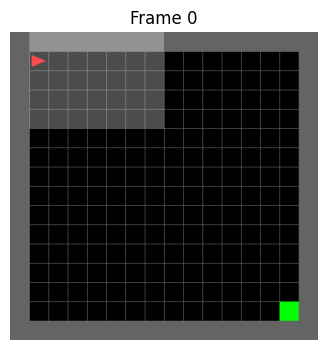

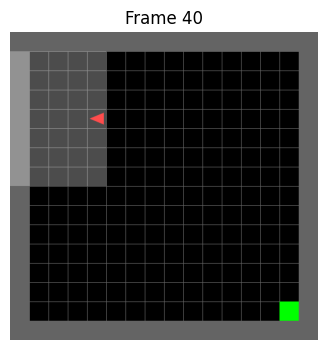

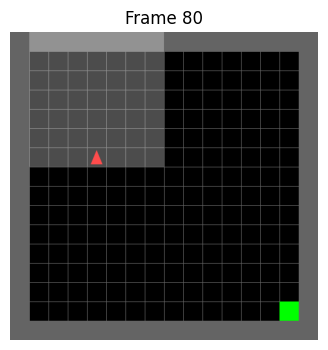

In [54]:
frames_random = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0",
    minigrid_random_policy,
    n_steps_max=80,
    seed=0
)

show_selected_frames(frames_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [55]:
from gymnasium.wrappers import RecordVideo

def record_policy_video(env_id, policy_fn, video_folder="video_out", seed=0, n_steps_max=150,
                        render_mode="rgb_array", policy_state_factory=None):
    if os.path.exists(video_folder):
        shutil.rmtree(video_folder)

    env = gym.make(env_id, render_mode=render_mode)
    env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda episode_id: True, disable_logger=True)

    obs, info = env.reset(seed=seed)
    terminated = truncated = False
    steps = 0
    policy_state = policy_state_factory() if policy_state_factory else None

    while not (terminated or truncated) and steps < n_steps_max:
        if policy_state is None:
            action = policy_fn(obs, info, env, steps)
        else:
            action = policy_fn(obs, info, env, steps, policy_state)

        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    mp4_files = glob.glob(os.path.join(video_folder, "*.mp4"))
    return mp4_files[0] if mp4_files else video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [56]:
video_path = record_policy_video(
    "MiniGrid-Empty-16x16-v0",
    minigrid_random_policy,
    video_folder="video_random_minigrid",
    seed=0,
    n_steps_max=120
)

print("Vidéo enregistrée dans :", video_path)

Vidéo enregistrée dans : video_random_minigrid\rl-video-episode-0.mp4


### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [57]:
video_random = record_policy_video(
    "MiniGrid-Empty-16x16-v0",
    minigrid_random_policy,
    video_folder="video_compare_random",
    seed=0,
    n_steps_max=120
)

video_reflex = record_policy_video(
    "MiniGrid-Empty-16x16-v0",
    minigrid_reflex_policy,
    video_folder="video_compare_reflex",
    seed=0,
    n_steps_max=120,
    policy_state_factory=reflex_policy_factory
)

video_memory = record_policy_video(
    "MiniGrid-Empty-16x16-v0",
    minigrid_memory_policy,
    video_folder="video_compare_memory",
    seed=0,
    n_steps_max=120,
    policy_state_factory=memory_policy_factory
)

print("Vidéo aléatoire :", video_random)
print("Vidéo réflexe   :", video_reflex)
print("Vidéo mémoire   :", video_memory)

Vidéo aléatoire : video_compare_random\rl-video-episode-0.mp4
Vidéo réflexe   : video_compare_reflex\rl-video-episode-0.mp4
Vidéo mémoire   : video_compare_memory\rl-video-episode-0.mp4


### Questions d'analyse visuelle

1. **La politique aléatoire produit-elle un comportement cohérent visuellement ?**  
   Non. Le mouvement paraît hésitant, peu structuré et souvent improductif.

2. **Quelle politique semble la plus efficace à l'observation ?**  
   La politique avec mémoire minimale paraît la plus cohérente parmi les politiques MiniGrid testées, car elle évite davantage les répétitions immédiates.

3. **Voyez-vous des hésitations, répétitions ou blocages ?**  
   Oui, surtout pour la politique aléatoire et la politique réflexe minimale, qui peuvent répéter des trajectoires ou tourner inutilement.

4. **Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?**  
   Oui. Les vidéos montrent clairement que les politiques les plus structurées atteignent plus facilement l’objectif et avec moins d’errance.

5. **Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?**  
   La comparaison visuelle est plus informative sur `MiniGrid`, car l’environnement spatial rend les trajectoires, hésitations et stratégies beaucoup plus visibles.

## Tableau comparatif entre analyse quantitative et analyse visuelle

| Environnement | Politique         | Reward moyenne | Succès | Observation visuelle |
|---|---|---:|---:|---|
| Taxi-v3 | Aléatoire | -790.167 | 0 % | La politique aléatoire produit un comportement instable et inefficace, avec de nombreuses actions non pertinentes. |
| Taxi-v3 | Heuristique | 7.840 | 100 % | La politique heuristique suit une logique claire : rejoindre le passager, effectuer le pickup, puis atteindre la destination. |
| MiniGrid | Aléatoire | 0.000 | 0 % | L’agent explore sans stratégie apparente, ce qui conduit à une forte errance dans la grille. |
| MiniGrid | Mémoire minimale | 0.976 | 100 % | L’ajout d’une mémoire minimale rend l’exploration plus cohérente et limite les répétitions immédiates. |